In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

from file_reading import pd_read_exp_file
import data_locs as LOCS
import lorentz_fit as lorentz
import plotting

## **Experiment B**

In [2]:
# lowest_harmonic = 274.25448868690813
lowest_harmonic = 125

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 60.0, 'current_temp': 47.29185250200002, 'current_temp_err': 0.008335831867230336}


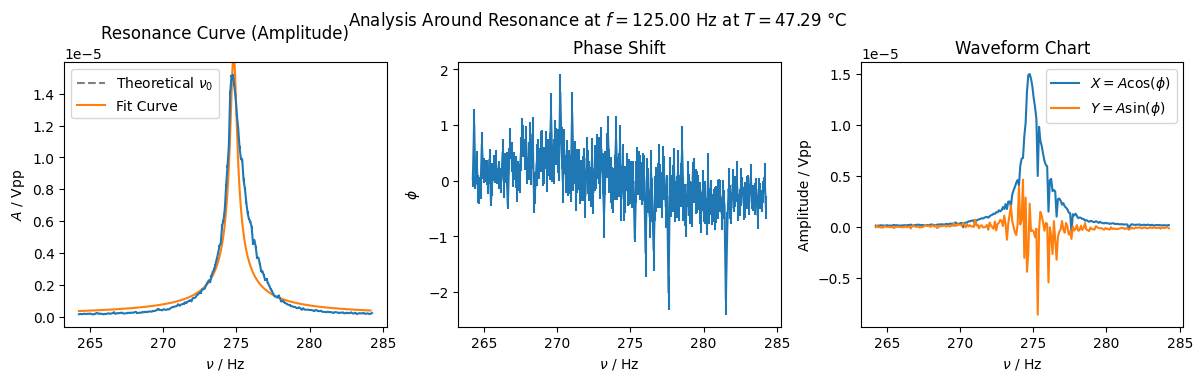

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 56.66666666666667, 'current_temp': 63.436495770000064, 'current_temp_err': 1.4210854715202004e-16}


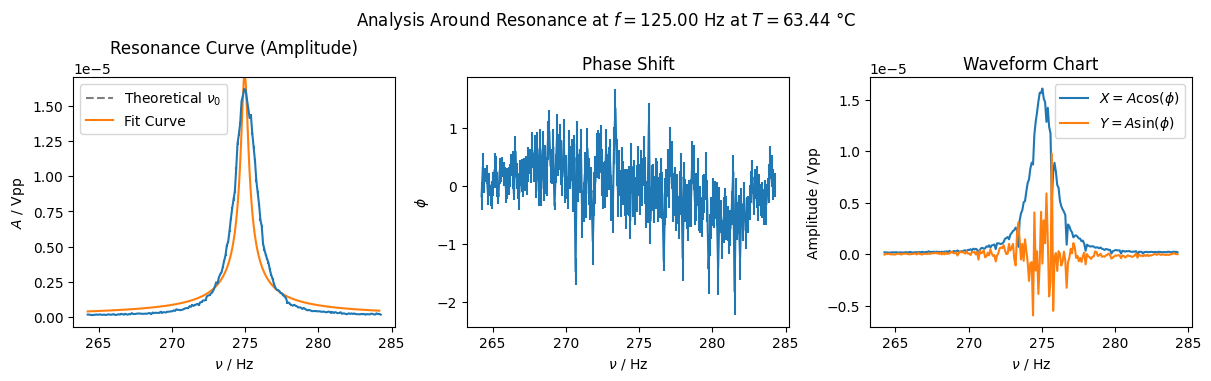

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 53.333333333333336, 'current_temp': 62.05200251400002, 'current_temp_err': 0.001947794297862154}


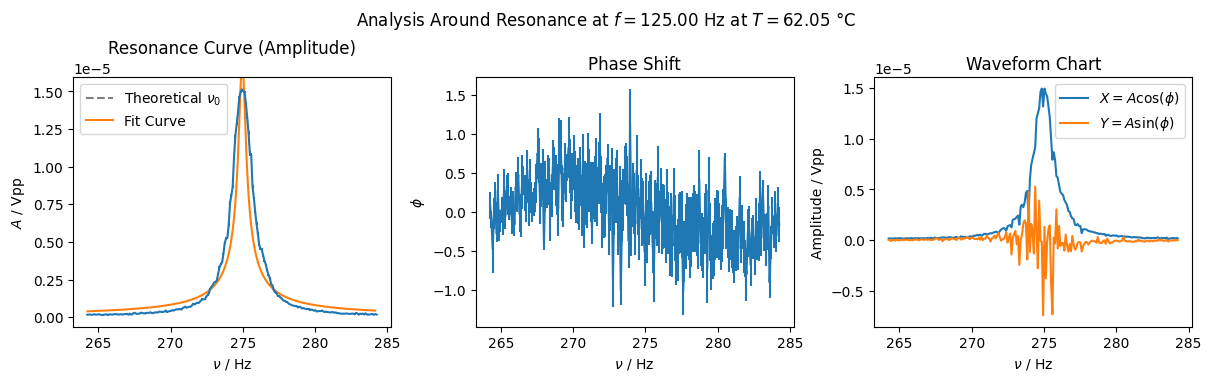

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 50.0, 'current_temp': 62.010519570000014, 'current_temp_err': 0.0022453302079854525}


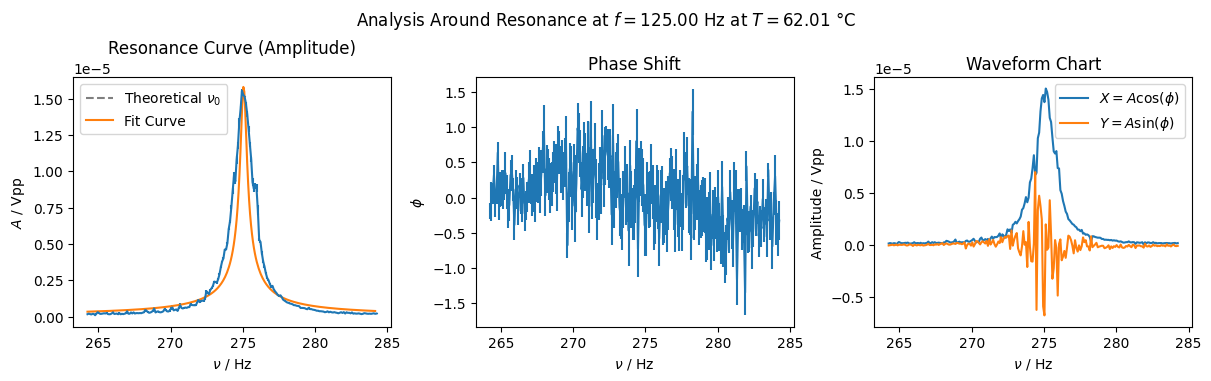

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 46.66666666666667, 'current_temp': 61.642358442, 'current_temp_err': 0.0010161204582844893}


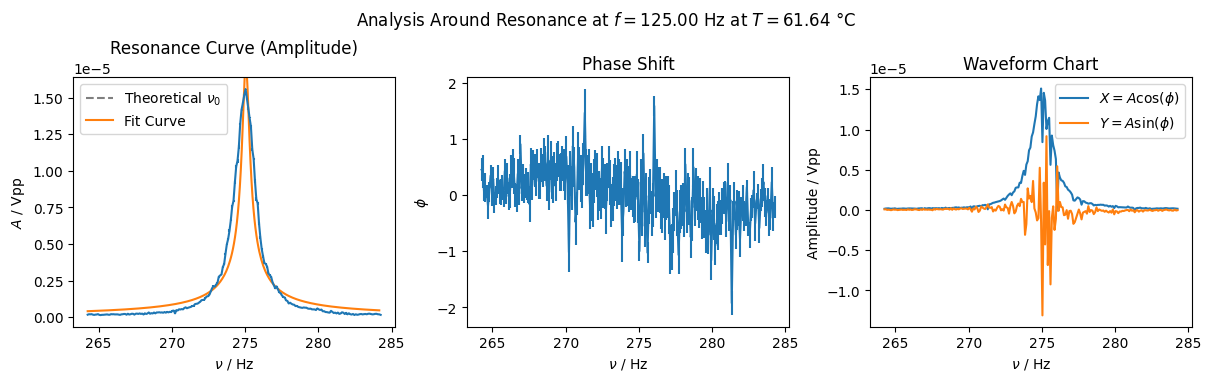

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 43.333333333333336, 'current_temp': 61.36494125400002, 'current_temp_err': 0.0036573389702678886}


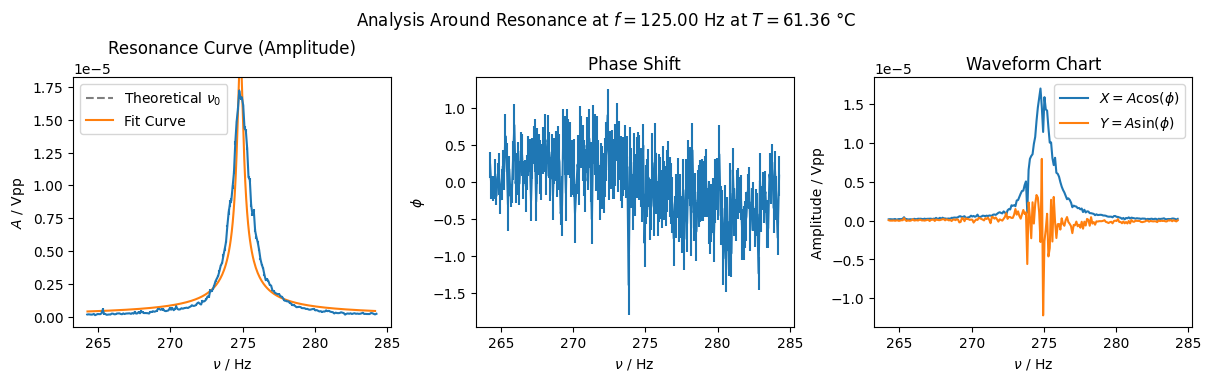

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 40.0, 'current_temp': 61.06937527800002, 'current_temp_err': 0.0035293848374945936}


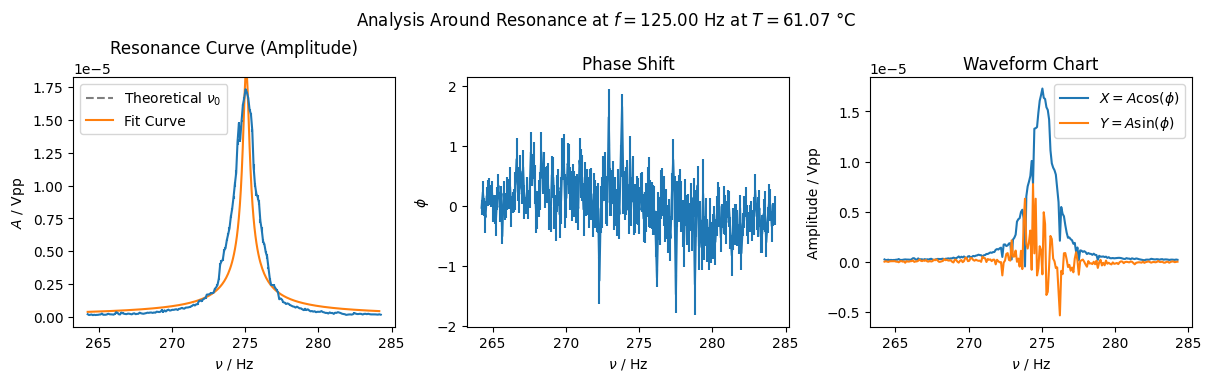

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 36.666666666666664, 'current_temp': 62.964627282000045, 'current_temp_err': 0.0014839577426918945}


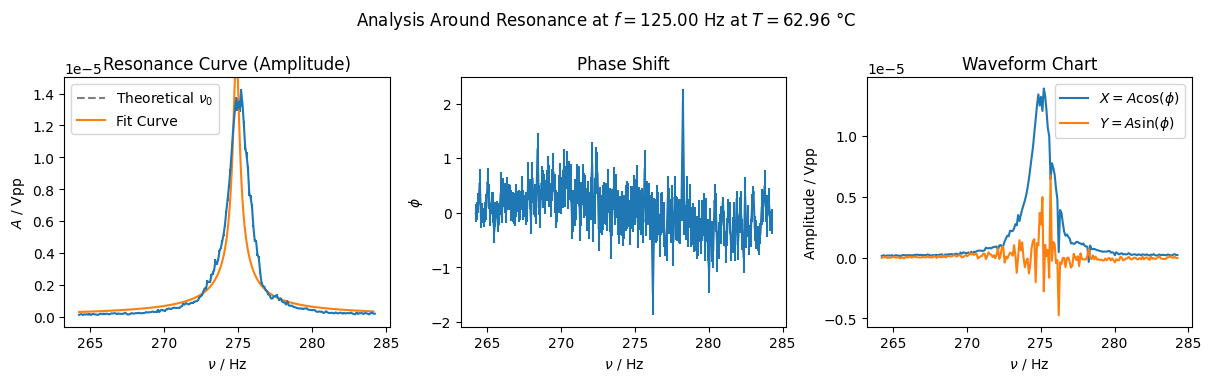

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 33.333333333333336, 'current_temp': 63.41575429800007, 'current_temp_err': 0.0010161204582844893}


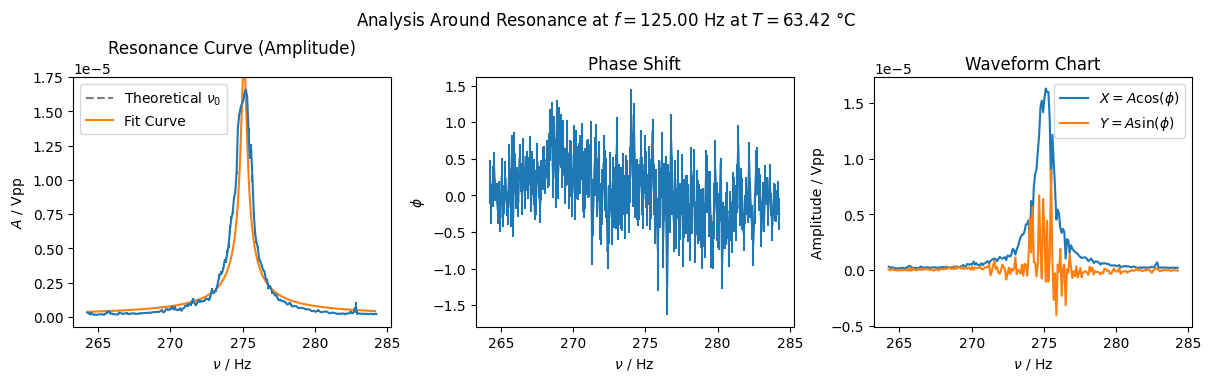

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 30.0, 'current_temp': 64.73283777000002, 'current_temp_err': 0.0}


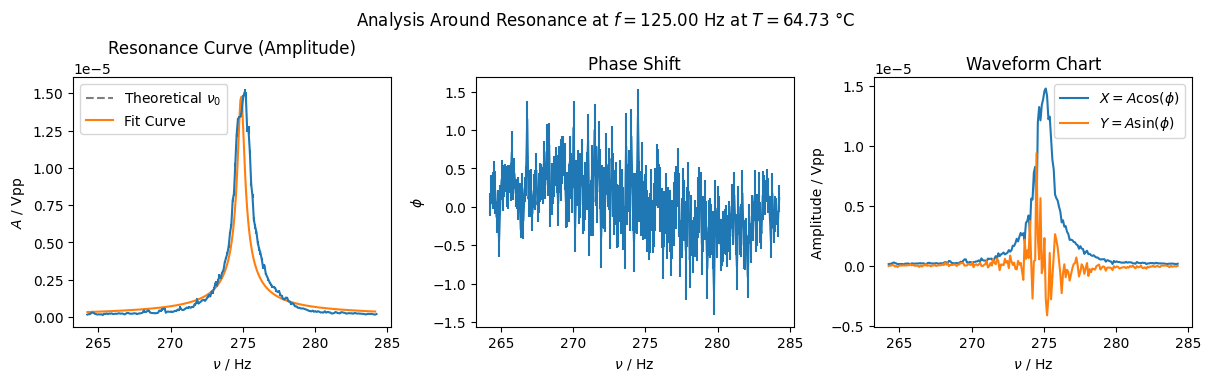

In [ ]:
locs = LOCS.final.expB[1]

fitparam_results: list[dict] = []

for i, loc in enumerate(locs):
    data, metadata = pd_read_exp_file(loc)
    print(metadata)
    temp = metadata["current_temp"]

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plotting.pd_freq_spectrum(fig, axs, data)
    for ax in axs:
        plotting.vertical_line(ax, lowest_harmonic, label=r"Theoretical $\nu_0$")

    result_dict = {"current_temp": metadata["current_temp"], 'target_freq': lowest_harmonic, "target_voltage": metadata.get("target_voltage")}
    min_idx, max_idx = (20, -20)
    min_idx, max_idx = (0, -1)
    result_dict = result_dict | lorentz.do_fit(axs[0], data["freq"][min_idx:max_idx], data["A"][min_idx:max_idx], data["A_err"][min_idx:max_idx])
    fitparam_results.append(result_dict)

    axs[0].legend()
    fig.suptitle(f"Analysis Around Resonance at $ f = {lowest_harmonic:.2f}$ Hz at $ T = {temp:.2f} $ °C")
    plt.show()

In [4]:
expB_df = pd.DataFrame(fitparam_results)
df = pd.DataFrame(fitparam_results)
df.pop('params_list')
df.pop('params_err_list')

display(df)

,current_temp,target_freq,target_voltage,f_0,f_0_err,omega_0,omega_0_err,gamma,gamma_err,fit_Q_factor,fit_Q_err
0,47.291853,125,None,0.080880,0.000183,1726.691678,0.006450,-2.827333,0.009907,-610.713993,-1.635004e+08
1,63.436496,125,None,0.093596,0.000194,1727.684124,0.006193,3.128145,0.008766,552.303137,1.540680e+08
2,62.052003,125,None,0.088187,0.000183,1727.638984,0.006323,3.002136,0.009878,575.469844,1.572321e+08
3,62.010520,125,None,0.076868,0.000216,1728.231888,0.010720,2.805556,0.010334,616.003278,9.931142e+07
4,61.642358,125,None,0.092564,0.000177,1728.206069,0.005031,-3.099803,0.009071,-557.521308,-1.915097e+08
5,61.364941,125,None,0.088106,0.000215,1726.838063,0.006447,2.538152,0.012304,680.352536,1.822472e+08
6,61.069375,125,None,0.089580,0.000204,1728.350925,0.005857,-2.735942,0.009026,-631.720683,-1.864082e+08
7,62.964627,125,None,0.073666,0.000203,1727.202785,0.011732,-2.553339,0.020160,-676.448753,-9.959028e+07
8,63.415754,125,None,0.085571,0.000218,1728.417112,0.006114,2.636194,0.011004,655.648616,1.853509e+08
9,64.732838,125,None,0.075988,0.000220,1727.159851,0.009735,-2.968126,0.012133,-581.902516,-1.032421e+08


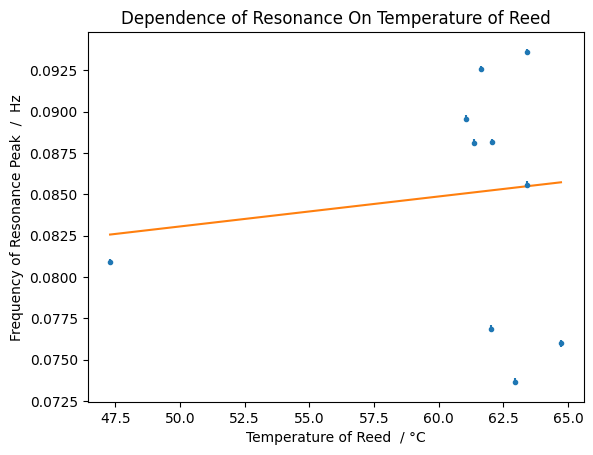

Temperature Coefficient: 0.00018129081849253852 ± 1.2589186797141693e-05


In [5]:
fig, ax = plt.subplots()
ax.errorbar(expB_df["current_temp"], expB_df["f_0"], yerr=expB_df["f_0_err"], linestyle="", marker='.')

params, pcov = curve_fit((lambda x, m, c: m * x + c), expB_df["current_temp"], expB_df["f_0"], sigma=expB_df["f_0_err"], absolute_sigma=True)
params_err = np.sqrt(np.diag(pcov))

xspace = np.linspace(np.min(expB_df["current_temp"]), np.max(expB_df["current_temp"]), 50)
ax.plot(xspace, params[0] * xspace + params[1])

ax.set_xlabel("Temperature of Reed  / °C")
ax.set_ylabel("Frequency of Resonance Peak  /  Hz")
ax.set_title("Dependence of Resonance On Temperature of Reed")

plt.show()

print(f"Temperature Coefficient: {params[0]} ± {params_err[0]}")

In [6]:
# part b
# fit each spectrum (g.o.f.)
# resonance frequencies against temp plot
# linear regression fit
# slope = temp coeff
# vorzeichen der steigung

